In [19]:
import pandas as pd
import numpy as np
import sys
from pathlib import Path

# Entity Resolution



### (1) Proliling base datasets

In [21]:
# ── path setup ────────────────────────────────────────────────
sys.path.append(str(Path().resolve().parent))
from src.config import DATA_RAW, DATA_PROCESSED

# ── reusable loader ───────────────────────────────────────────
def load_raw(filename, **kwargs):
    """Load a raw CSV from data/raw folder."""
    return pd.read_csv(DATA_RAW / filename, low_memory=False, **kwargs)

# ── reusable profiler ─────────────────────────────────────────
def quick_profile(df, name="DataFrame"):
    """Print shape, dtypes, missing rates."""
    print(f"\n{'='*50}")
    print(f"{name}: {df.shape[0]:,} rows × {df.shape[1]} cols")
    print(f"{'='*50}")

    print("\nColumns + dtypes:")
    print(df.dtypes.to_string())

    print("\nMissing value rates (%):")
    missing = (df.isnull().sum() / len(df) * 100).round(2)
    print(missing[missing > 0].to_string() if missing.any() else "  None")
    print()
    
    return df.head(3)


In [23]:
# ── load all core ETS files ───────────────────────────────────
installation   = load_raw('installation.csv')
account        = load_raw('account.csv')
account_holder = load_raw('account_holder.csv')
compliance     = load_raw('compliance.csv')
surrender      = load_raw('surrender.csv')
account_type   = load_raw('account_type.csv')
activity_type = load_raw('activity_type.csv')

In [24]:
for df, name in [
    (installation,   "Installation"),
    (account,        "Account"),
    (account_holder, "Account Holder"),
    (compliance,     "Compliance"),
    (surrender,      "Surrender"),
    (activity_type,  "Activity Type")
    (account_type,   "Account Type"),
]:
    quick_profile(df, name)


Installation: 19,624 rows × 39 cols

Columns + dtypes:
id                         object
name                       object
tradingSystem_id           object
registry_id                object
activity_id                 int64
eprtrID                   float64
parentCompany              object
subsidiaryCompany          object
permitID                   object
designatorICAO            float64
monitoringID               object
monitoringExpiry          float64
monitoringFirstYear        object
permitDateExpiry           object
isAircraftOperator         object
isMaritimeOperator         object
ec748_2009Code             object
permitDateEntry            object
addressMain                object
addressSecondary           object
postalCode                 object
city                       object
country_id                 object
latitudeEutl              float64
longitudeEutl             float64
latitudeGoogle            float64
longitudeGoogle           float64
nace15_id                 

Some key observations

Installation table:

- parentCompany and subsidiaryCompany columns exist — useful for corporate structure, but 12% and 72% missing respectively so not reliable as primary matching method
- activity_id — links to activity_type, good for sector/activity classification later
- nace_id — industry classification, only 7% missing, keep this
- country_id — good, low missing
- Aircraft (isAircraftOperator) and maritime (isMaritimeOperator) indicate whether installations are aircrafts/maritime installations

Account table:

- bvdId — 30% missing (major gap to deal with)
- installation_id — 28% missing, meaning many accounts are not linked to installations (these are trader/financial accounts, not operator accounts — can be filtered out)
- isOpen — important filter, only want open accounts
- companyRegistrationNumber — useful backup identifier when BvD ID is missing


Account Holder table:

- legalEntityIdentifier — this is the LEI, 85% missing unfortunately, not useful as primary identifier name, city, country_id — useful for manual matching fallback

Compliance table:

- High missingness on key columns (~60%) — this is expected, installations only report when active in a given year
allocatedFree and verified are the two most important columns for carbon intensity calculation later


Surrender table:

- unitType_id — only 0.02% missing, clean. Filter to EUA only later
- project_id — 88% missing, confirms most surrenders are EUAs not offsets

### (2) Mapping Strategy

installation.id 

- account.installation_id (filter: isOpen=True, installation accounts only)
- account.bvdId (primary) or account.companyRegistrationNumber (fallback)
- account_holder.id (for name/country when both identifiers missing)
    

    
stage 1: Filter open installations

stage 2: Filter accounts: 

stage 3: Linking installations to accounts (note, many to one mapping)

stage 4: Building bvdid universe


In [46]:
# SECTION 1: FILTER INSTALLATIONS

def filter_installations(installation, activity_type):
    """
    Load all installations across all operator types (stationary, aircraft, maritime).
    Flags operator type for downstream filtering/analysis.
    Intensity metric per operator type to be determined at feature engineering stage.
    
    Stationary:  tonnes CO2 / revenue (€M)
    Aircraft:    to be determined - designatorICAO available for matching
    Maritime:    to be determined - imoID available for matching
    """
    df = installation.copy()
    df['id'] = df['id'].astype(str).str.strip()

    # flag operator type (stationary installations, aircraft, maritime)
    conditions = [
        df['isAircraftOperator'] == True,
        df['isMaritimeOperator'] == True
    ]
    choices = ['aircraft','maritime']
    df['operator_type'] = np.select(conditions, choices, default='stationary')

    print("Operator type breakdown:")
    print(df['operator_type'].value_counts().to_string())
    print(f"Total installations: {len(df):,}")

    # merge activity type description
    df = df.merge(
        activity_type[['id', 'description']].rename(columns={
            'id': 'activity_id_ref',
            'description': 'activity_description'
        }),
        left_on='activity_id',
        right_on='activity_id_ref',
        how='left'
    )

    keep_cols = [
        'id', 'name', 'country_id', 'operator_type',
        'activity_id', 'activity_description',
        'nace_id', 'parentCompany', 'subsidiaryCompany',
        'addressMain', 'city', 'postalCode',
        'designatorICAO',   # aircraft matching identifier
        'imoID'             # maritime matching identifier
    ]
    return df[keep_cols].copy()


In [47]:
installation_filtered = filter_installations(installation, activity_type)

Operator type breakdown:
operator_type
stationary    16511
aircraft       1675
maritime       1438
Total installations: 19,624


In [48]:
quick_profile(installation_filtered, "Filtered Installations")


Filtered Installations: 19,624 rows × 14 cols

Columns + dtypes:
id                       object
name                     object
country_id               object
operator_type            object
activity_id               int64
activity_description     object
nace_id                 float64
parentCompany            object
subsidiaryCompany        object
addressMain              object
city                     object
postalCode               object
designatorICAO          float64
imoID                   float64

Missing value rates (%):
country_id            0.14
nace_id               7.35
parentCompany        12.72
subsidiaryCompany    72.15
addressMain           0.14
city                  0.16
postalCode            0.20
designatorICAO       91.46
imoID                92.67



,id,name,country_id,operator_type,activity_id,activity_description,nace_id,parentCompany,subsidiaryCompany,addressMain,city,postalCode,designatorICAO,imoID
0,AT_200165,28567,AT,aircraft,10,Aircraft operator activities,51.0,OE-HMR,NaN,-,-,-,2019.0,NaN
1,AT_200180,209,AT,aircraft,10,Aircraft operator activities,51.0,NaN,NaN,-,-,-,0.0,NaN
2,AT_200146,440,AT,aircraft,10,Aircraft operator activities,51.0,AUA,NaN,-,-,-,0.0,NaN


In [93]:
# ============================================================
# SECTION 2.1: UNDERSTANDING ACCOUNT TYPES
# ============================================================
def linking_account_types(account, account_type):
    """
    Merging account types to accounts
    Understanding how account types map to installations
    """
    df = account.copy()
    df['accountType_id'] = df['accountType_id'].astype(str).str.strip()
    df['accountType_id'] = df['accountType_id'].replace('nan', np.nan)
    
    # merging account type descriptions to accounts:
    df = df.merge(account_type.rename(
        columns={
            'id':'account_type_id_ref',
            'description': 'account_type_description'
        }),
        left_on = 'accountType_id',
        right_on = 'account_type_id_ref',
        how = 'left'
    )

    # see the missing rates for each account types
    print("\nMissing value rates (%) by each account types:")
    
    # missing = (df.isnull().sum() / len(df) * 100).round(2)
    missing = df.groupby('account_type_description')['installation_id'].apply(lambda x: (x.isna().sum()/len(x)))
    print(missing.sort_values())

    return df

In [155]:
linked_account = linking_account_types(account, account_type)


Missing value rates (%) by each account types:
account_type_description
Aircraft Operator Account                                                       0.000000
Operator Holding Account                                                        0.000000
EU Effort Sharing Account                                                       0.008850
Former Operator Holding Account                                                 0.015537
AAU Deposit Account                                                             1.000000
Net Source Cancellation Account (Type 1)                                        1.000000
New Entrant Reserve Account                                                     1.000000
Non-compliance Cancellation Account (Type 2)                                    1.000000
Party Holding Account                                                           1.000000
Person Account in National Registry                                             1.000000
Person Holding Account               

for most types of accounts, there are not any associated installation ids. The only pertinent accounts with installation ids are:
- Aircraft Operator Account 
- Operator Holding Account
- EU Effort Sharing Account 
- Former Operator Holding Account


EU effort sharing account will be excluded as they are not in the ETS systems (accountId is 'esd')

In [167]:
# ============================================================
# SECTION 2.2: Filtering account types
# ============================================================

def filter_operator_accounts(account):
    """
    Removes trader/financial accounts (no installation_id).
    Removes EU effort sharing account (id 'esd')
    Keeps accounts that were active at any point during study period.
    Closed accounts retained if they were open during 2018-2024.
    Understanding account identifier coverage
    """
    from src.config import START_DATE, END_DATE
    
    df = account.copy()
    df['installation_id'] = df['installation_id'].astype(str).str.strip()
    df['installation_id'] = df['installation_id'].replace('nan', np.nan)

    # keep only accounts linked to installations
    pre = len(df)
    df = df[df['installation_id'].notna()]
    print(f"Removed {pre - len(df):,} non-installation accounts (traders etc.)")

    # Remove EU effort sharing account (id 'esd')
    pre_esd = len(df)
    df = df[df['accountType_id'] != 'esd']
    print(f"\nRemoved {pre_esd - len(df):,} non-ETS accounts (EU Effort Sharing etc.)")
    
    # convert dates
    df['openingDate'] = pd.to_datetime(df['openingDate'], errors='coerce')
    df['closingDate'] = pd.to_datetime(df['closingDate'], errors='coerce')

    study_start = pd.to_datetime(START_DATE)
    study_end = pd.to_datetime(END_DATE)

    # Check if all closed accounts have closing dates:
    df['has_closing_date'] = df['closingDate'].notna()
    print(f"\nAcconts Opening Status and Closing Dates:")
    print(f"{df.value_counts(subset=['isOpen', 'has_closing_date'])}")

    # keep if:
    # 1. account is still open (no closing date), OR
    # 2. account closed after study period started (was active during 2018-2024)
    
    pre = len(df)
    df = df[
        df['closingDate'].isna() |                        # still open 
        (df['closingDate'] >= study_start)                # closed after 2018
    ]
    print(f"\nRemoved {pre - len(df):,} accounts closed before study period", END_DATE )

    # flag whether account is currently open or closed during period
    df['account_status'] = 'open'
    df.loc[df['closingDate'].notna(), 'account_status'] = 'closed_during_period'
    
    print(f"Remaining accounts: {len(df):,}")
    print(f"\nAccount status breakdown:")
    print(df['account_status'].value_counts().to_string())

    # identifier coverage
    df['has_bvdid'] = df['bvdId'].notna()
    df['has_registration'] = df['companyRegistrationNumber'].notna()

    print(f"\nIdentifier coverage:")
    print(f"  Total:                   {len(df):,}")
    print(f"  Has BvD ID:              {df['has_bvdid'].sum():,} ({df['has_bvdid'].mean()*100:.1f}%)")
    print(f"  Has registration number: {df['has_registration'].sum():,} ({df['has_registration'].mean()*100:.1f}%)")
    print(f"  Has neither:             {(~df['has_bvdid'] & ~df['has_registration']).sum():,}")

    print(f"\nAccount Types:")
    print(f"{df['account_type_description'].value_counts()}")
    
    keep_cols = [
        'id', 'installation_id', 'name', 'registry_id',
        'accountHolder_id', 'accountType_id', 'bvdId',
        'companyRegistrationNumber', 'companyRegistrationNumberType',
        'openingDate', 'closingDate', 'account_status',
        'has_bvdid', 'has_registration','account_type_description'
    ]
    return df[keep_cols].copy()

In [231]:
accounts_filtered = filter_operator_accounts(linked_account)

Removed 12,913 non-installation accounts (traders etc.)

Removed 224 non-ETS accounts (EU Effort Sharing etc.)

Acconts Opening Status and Closing Dates:
isOpen  has_closing_date
False   True                18591
True    False               13721
False   False                  83
Name: count, dtype: int64

Removed 14,665 accounts closed before study period 2024-12-31
Remaining accounts: 17,730

Account status breakdown:
account_status
open                    13804
closed_during_period     3926

Identifier coverage:
  Total:                   17,730
  Has BvD ID:              13,558 (76.5%)
  Has registration number: 17,350 (97.9%)
  Has neither:             380

Account Types:
account_type_description
Operator Holding Account           12286
Former Operator Holding Account     2438
Aircraft Operator Account           1568
Name: count, dtype: int64


In [232]:
quick_profile(accounts_filtered)


DataFrame: 17,730 rows × 15 cols

Columns + dtypes:
id                                        int64
installation_id                          object
name                                     object
registry_id                              object
accountHolder_id                        float64
accountType_id                           object
bvdId                                    object
companyRegistrationNumber                object
companyRegistrationNumberType            object
openingDate                      datetime64[ns]
closingDate                      datetime64[ns]
account_status                           object
has_bvdid                                  bool
has_registration                           bool
account_type_description                 object

Missing value rates (%):
accountType_id                    8.11
bvdId                            23.53
companyRegistrationNumber         2.14
companyRegistrationNumberType    18.42
openingDate                      11.88
closin

,id,installation_id,name,registry_id,accountHolder_id,accountType_id,bvdId,companyRegistrationNumber,companyRegistrationNumberType,openingDate,closingDate,account_status,has_bvdid,has_registration,account_type_description
70,90705,AT_200180,Air Charter Limited,AT,90705.0,100-9,NaN,FL-0001.021.205-3,NaN,2012-02-23 16:34:49,NaT,open,False,True,Aircraft Operator Account
71,90730,AT_200165,Tupack Verpackungen Gesellschaft m.b.H.,AT,90730.0,100-9,AT9110011483,60238 k,trade_register_number,2012-02-22 12:47:26,2020-05-13 14:44:54,closed_during_period,True,True,Aircraft Operator Account
72,90423,AT_200146,Austrian Airlines AG,AT,90423.0,100-9,AT9110044307,111 000k,trade_register_number,2012-02-21 15:22:44,NaT,open,True,True,Aircraft Operator Account


Some things to clean for accounts filtered
- change all ids to string object (id, accountHolder_id)
- print out columns with values with variants of 'None'

In [282]:
# ============================================================
# SECTION 2.3: Cleaning Accounts Dataframes
# ============================================================

def clean_id_columns(accounts_filtered):
    """
    change all ids into string objects
    """
    df = accounts_filtered.copy()

    # Change identifier columns to string objects:
    id_cols = ['id', 'installation_id', 'name', 'registry_id',
               'accountHolder_id','accountType_id', 'bvdId', 'companyRegistrationNumber']
    ets_ids = ['id', 'installation_id', 'name', 'registry_id',
               'accountHolder_id','accountType_id']
    
    df['accountHolder_id'] = df['accountHolder_id'].astype(int)
    df[id_cols] = df[id_cols].apply(lambda x: x.astype(str))
    df[ets_ids] = df[ets_ids].apply(lambda x: x.str.strip())
    df[id_cols] = df[id_cols].apply(lambda x: x.replace('nan', np.nan))
    
    return df

In [283]:
accounts_filtered = clean_id_columns(accounts_filtered)

In [284]:
quick_profile(accounts_filtered)


DataFrame: 17,730 rows × 15 cols

Columns + dtypes:
id                                       object
installation_id                          object
name                                     object
registry_id                              object
accountHolder_id                         object
accountType_id                           object
bvdId                                    object
companyRegistrationNumber                object
companyRegistrationNumberType            object
openingDate                      datetime64[ns]
closingDate                      datetime64[ns]
account_status                           object
has_bvdid                                  bool
has_registration                           bool
account_type_description                 object

Missing value rates (%):
accountType_id                    8.11
bvdId                            23.53
companyRegistrationNumber         2.14
companyRegistrationNumberType    18.42
openingDate                      11.88
closin

,id,installation_id,name,registry_id,accountHolder_id,accountType_id,bvdId,companyRegistrationNumber,companyRegistrationNumberType,openingDate,closingDate,account_status,has_bvdid,has_registration,account_type_description
70,90705,AT_200180,Air Charter Limited,AT,90705,100-9,NaN,FL-0001.021.205-3,NaN,2012-02-23 16:34:49,NaT,open,False,True,Aircraft Operator Account
71,90730,AT_200165,Tupack Verpackungen Gesellschaft m.b.H.,AT,90730,100-9,AT9110011483,60238 k,trade_register_number,2012-02-22 12:47:26,2020-05-13 14:44:54,closed_during_period,True,True,Aircraft Operator Account
72,90423,AT_200146,Austrian Airlines AG,AT,90423,100-9,AT9110044307,111 000k,trade_register_number,2012-02-21 15:22:44,NaT,open,True,True,Aircraft Operator Account


In [285]:
# ============================================================
# SECTION 3: Linking Installations to Accounts
# ============================================================

def link_installations_to_accounts(installation_filtered, accounts_filtered):
    """
    Merge accounts with installations.
    One account may link to multiple installations.
    One installation generally belongs to one account.
    Carries through operator_type and account_status for downstream use.
    """

    starting_installations = len(installation_filtered)
    
    df = accounts_filtered.merge(
        installation_filtered,
        left_on='installation_id',
        right_on='id',
        how='left', # all starting accounts should remain in the merged table
        suffixes=('_account', '_install')
    )

    # installation summary:
    matched_installations = df['installation_id'].nunique()
    unmatched_installations = starting_installations - matched_installations

    # Find unmatched installations:
    unmatched_installation_df = installation_filtered[~installation_filtered['id'].isin(df['id_install'])]

    # identifier summary:
    total = len(accounts_filtered)
    matched_bvd = df['bvdId'].notna().sum()
    matched_reg = (df['bvdId'].isna() & df['companyRegistrationNumber'].notna()).sum()
    no_identifier = (df['bvdId'].isna() & df['companyRegistrationNumber'].isna()).sum()

    print(f"Account → Installation mapping:")
    print(f"  Starting installations (n):                     {starting_installations:,}")
    print(f"  Matched installations (n):                      {matched_installations:,}")
    print(f"  Unmatched installations (n):                     {unmatched_installations:,}")

    print(f"accounts with identifiers")
    print(f"  Total (starting) accounts:            {total:,}")
    print(f"  Matched with BvD ID:                  {matched_bvd:,} ({matched_bvd/total*100:.1f}%)")
    print(f"  Matched with registration only:       {matched_reg:,} ({matched_reg/total*100:.1f}%)")
    print(f"  No identifier (manual review):        {no_identifier:,} ({no_identifier/total*100:.1f}%)")

    # accounts with multiple installations (by accountholder id)
    install_counts = (
        df.groupby('accountHolder_id')['id_install']
        .count()
        .reset_index()
        .rename(columns={'accountHolder_id': 'accountHolder_id', 
                         'id_install': 'installation_count'})
    )

    multi = (install_counts['installation_count'] > 1).sum()
    print(f"\nAccounts with multiple installations: {multi:,}")

    # operator type breakdown in final map
    print(f"\nOperator type breakdown in map:")
    print(df['operator_type'].value_counts().to_string())

    return df, install_counts, unmatched_installation_df

In [286]:
installation_account_map, multi_installs, unmapped_installation = link_installations_to_accounts(
    installation_filtered, accounts_filtered
)

Account → Installation mapping:
  Starting installations (n):                     19,624
  Matched installations (n):                      15,380
  Unmatched installations (n):                     4,244
accounts with identifiers
  Total (starting) accounts:            17,730
  Matched with BvD ID:                  13,558 (76.5%)
  Matched with registration only:       3,792 (21.4%)
  No identifier (manual review):        380 (2.1%)

Accounts with multiple installations: 3,168

Operator type breakdown in map:
operator_type
stationary    14724
aircraft       1568
maritime       1438


The 4,244 unmatched installations didn't find a corresponding open/active account in our filtered accounts table.

These are likely:

- Installations whose accounts were closed before 2018
- Data gaps in the EUTL linking


total unique installations with corresponding to unmapped accounts:  4244

total unique accounts with corresponding to unmapped installations:  8242 



/var/folders/bg/1y0v_kw15cnb9w8c866jb_280000gn/T/ipykernel_67267/1744203659.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  accounts_unmapped[dates_cols] = accounts_unmapped[dates_cols].apply(lambda x: x.str.split(' ').str[0])
/var/folders/bg/1y0v_kw15cnb9w8c866jb_280000gn/T/ipykernel_67267/1744203659.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  accounts_unmapped[dates_cols] = accounts_unmapped[dates_cols].apply(lambda x: pd.to_datetime(x))


<Axes: xlabel='closingDate'>

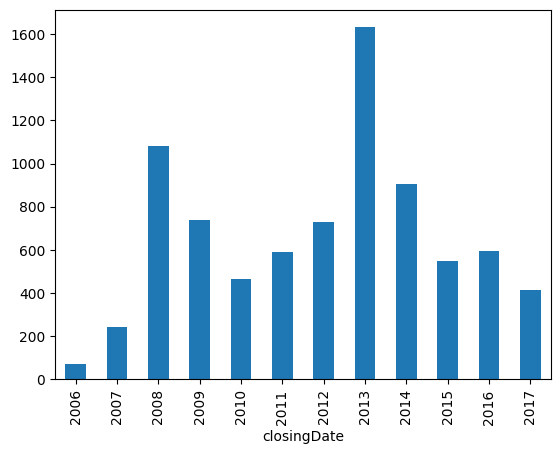

In [344]:
# Confirming the unmapped installations:

unmatched_install_ids = set(
    unmapped_installation['id'].dropna().unique()
)
accounts_unmapped = account[account['installation_id'].isin(unmatched_install_ids)]

print('\ntotal unique installations with corresponding to unmapped accounts: ', accounts_unmapped['installation_id'].nunique())
print('\ntotal unique accounts with corresponding to unmapped installations: ', accounts_unmapped['id'].nunique(), '\n')

dates_cols = ['openingDate','closingDate']
accounts_unmapped[dates_cols] = accounts_unmapped[dates_cols].apply(lambda x: x.str.split(' ').str[0])
accounts_unmapped[dates_cols] = accounts_unmapped[dates_cols].apply(lambda x: pd.to_datetime(x))
accounts_unmapped.groupby(accounts_unmapped['closingDate'].dt.to_period('Y')).size().plot(kind='bar')


This confirms that unmapped all installations are those with accounts that were closed before 2018 (study start date)

In [368]:
# ============================================================
# SECTION 4: BUILD BVD ID UNIVERSE
# ============================================================

def build_bvdid_universe(installation_account_map, account_holder):
    """
    Extract unique BvD IDs with supporting information.
    For installations missing BvD ID, retain account holder 
    name and country for manual matching later.
    """
    df = installation_account_map.copy()
    
    # merge account holder info for fallback identification
    account_holder_slim = account_holder[[
        'id', 'name', 'city', 'country_id', 'legalEntityIdentifier'
    ]].rename(columns={
        'id': 'accountHolder_id',
        'name': 'holder_name',
        'city': 'holder_city',
        'country_id': 'holder_country',
        'legalEntityIdentifier': 'lei'
    })
    
    account_holder_slim['accountHolder_id'] = account_holder_slim['accountHolder_id'].astype(str)
    account_holder_slim['accountHolder_id'] = account_holder_slim['accountHolder_id'].replace('nan',np.nan)

    df['accountHolder_id'] = df['accountHolder_id'].astype(str)
    df['accountHolder_id'] = df['accountHolder_id'].replace('nan', np.nan)

    df = df.merge(account_holder_slim, on='accountHolder_id', how='left')
    
    # summarise at BvD ID level
    # (one BvD ID may have multiple installations)
    bvdid_universe = df.groupby('bvdId', dropna=True).agg(
        installation_count=('installation_id', 'nunique'),
        countries=('country_id', lambda x: list(x.dropna().unique())),
        activities=('activity_description', lambda x: list(x.dropna().unique())),
        holder_name=('holder_name', 'first'),
        holder_country=('holder_country', 'first'),
        registration_number=('companyRegistrationNumber', 'first'),
        registration_type=('companyRegistrationNumberType','first'),
        lei=('lei', 'first')
    ).reset_index()
    
    print(f"Unique BvD IDs identified: {len(bvdid_universe):,}")
    print(f"Multi-installation companies: "
          f"{(bvdid_universe['installation_count'] > 1).sum():,}")
    
    # separately flag unmatched installations for manual review
    unmatched = df[df['bvdId'].isna()][[
        'installation_id', 'name_install', 'country_id',
        'companyRegistrationNumber', 'holder_name', 'holder_country'
    ]].drop_duplicates()
    print(f"Installations without BvD ID (manual review needed): {len(unmatched):,}")
    
    return df, bvdid_universe, unmatched


In [366]:
installation_account_map['bvdId'].nunique()

6803

In [369]:

full_df, bvdid_universe, unmatched_installations = build_bvdid_universe(
    installation_account_map, account_holder
)

Unique BvD IDs identified: 6,803
Multi-installation companies: 1,633
Installations without BvD ID (manual review needed): 3,959


In [371]:
# ============================================================
# SECTION 5: EXPORT
# ============================================================

def export_processed(df, filename):
    """Save processed file to data/processed folder."""
    path = DATA_PROCESSED / filename
    df.to_csv(path, index=False)
    print(f"Saved: {path} ({len(df):,} rows)")

export_processed(full_df, 'full_ets_samples.csv')
export_processed(bvdid_universe, 'ets_bvdid_universe.csv')
export_processed(unmatched_installations, 'ets_unmatched_installations.csv')

Saved: /Users/admin/Desktop/carbon-portfolio-project-v2/data/processed/full_ets_samples.csv (17,730 rows)
Saved: /Users/admin/Desktop/carbon-portfolio-project-v2/data/processed/ets_bvdid_universe.csv (6,803 rows)
Saved: /Users/admin/Desktop/carbon-portfolio-project-v2/data/processed/ets_unmatched_installations.csv (3,959 rows)


In [373]:
bvdid_list = bvdid_universe['bvdId'].tolist()

with open('ets_bvdid.txt', 'w') as f:
    for item in bvdid_list:
        f.write(f"{item}\n")